STEP 1. 데이터 준비
Train : 930명  |  Test : 233명
피처  : 14개 (Cox와 동일)
평가  : 82일 ~ 1559일

피처 목록:
  Age
  Sex
  Prior_cancer
  Grade_G2
  Grade_G3
  Grade_G4
  Site_BrainNOS
  Site_Cerebrum
  Site_Other
  Era_After2005
  Era_Before2005
  Tx_Single
  Tx_Standard
  Tx_None

STEP 2. RSF — Grid Search CV
총 36개 조합 × 5-Fold = 180번 학습
  [ 10/36] 현재 최고 CV: 0.782
  [ 20/36] 현재 최고 CV: 0.783
  [ 30/36] 현재 최고 CV: 0.783
  [ 36/36] 현재 최고 CV: 0.785

✓ 최적 파라미터 : {'max_features': 0.5, 'min_samples_leaf': 15, 'n_estimators': 200, 'n_jobs': -1}
✓ CV C-index    : 0.785
✓ table_rsf_gridsearch.csv 저장 완료

[ RSF 과적합 검증 — 5-Fold CV ]
  Fold 1: C-index = 0.786
  Fold 2: C-index = 0.772
  Fold 3: C-index = 0.815
  Fold 4: C-index = 0.781
  Fold 5: C-index = 0.773

Model   : RSF
──────────────────────────────────────────────────
최적 파라미터 : {'max_features': 0.5, 'min_samples_leaf': 15, 'n_estimators': 200, 'n_jobs': -1}
──────────────────────────────────────────────────
C-index  Train : 0.799
C-index  Test  : 0.783  ← 비교 기

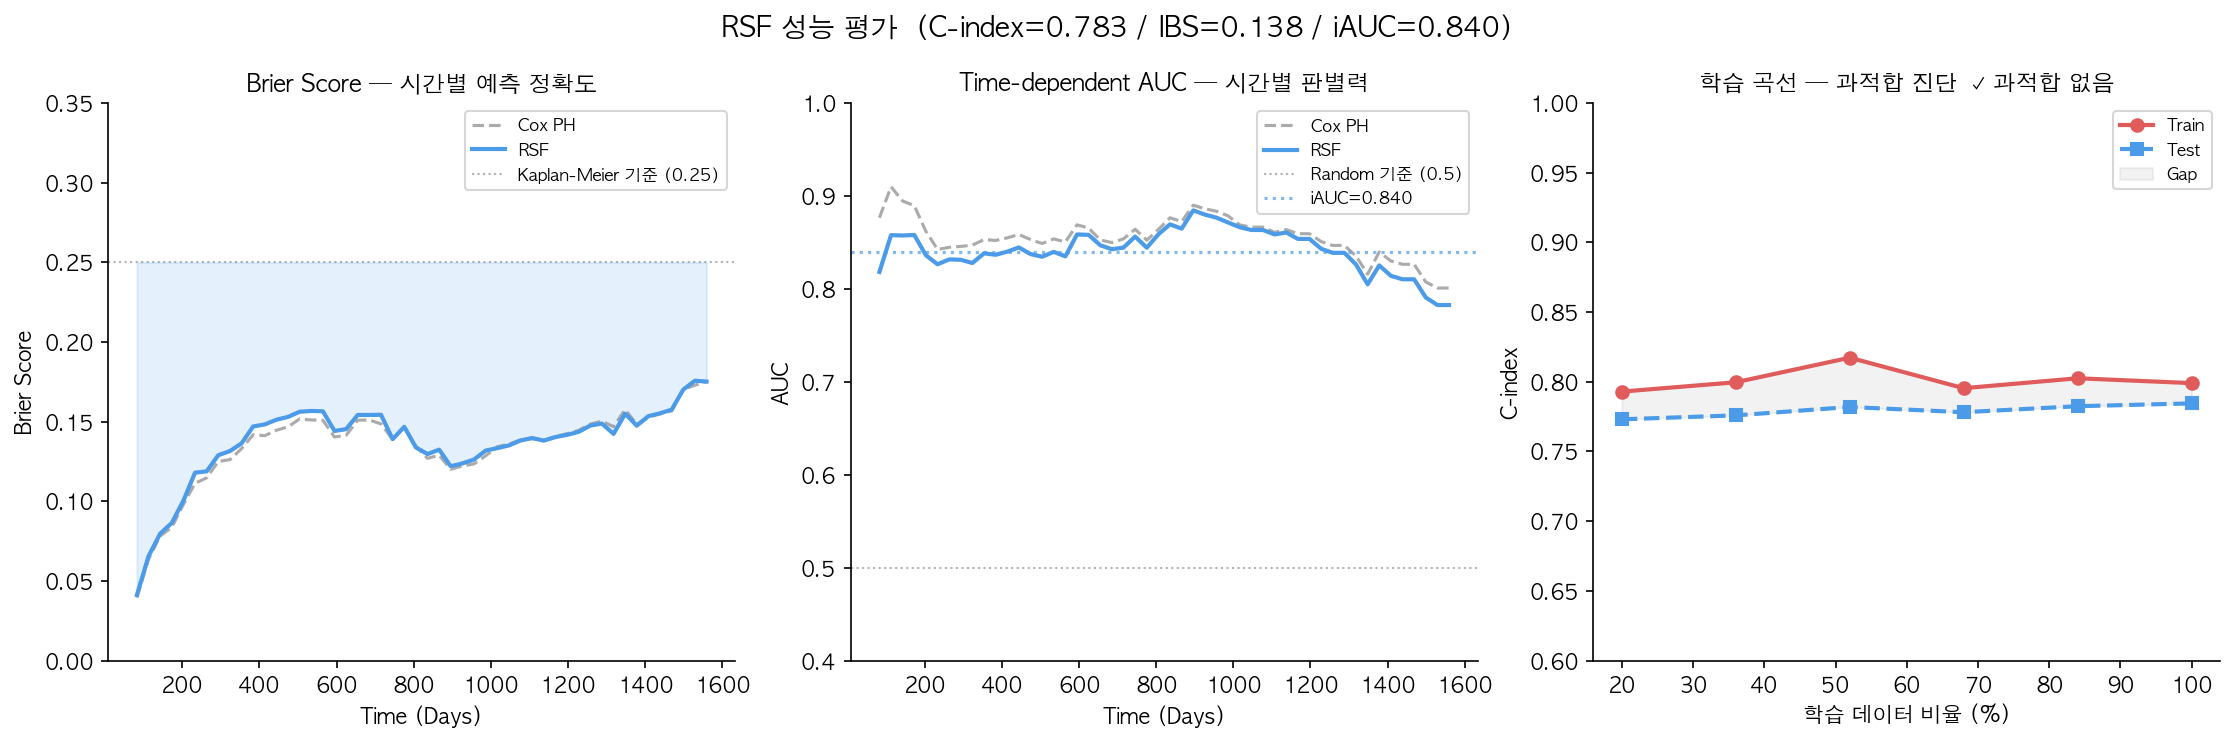

✓ fig_rsf_performance.png 저장 완료

STEP 3. GBM — Grid Search CV
총 81개 조합 × 5-Fold = 405번 학습
  [ 10/81] 현재 최고 CV: 0.784
  [ 20/81] 현재 최고 CV: 0.784
  [ 30/81] 현재 최고 CV: 0.784
  [ 40/81] 현재 최고 CV: 0.785
  [ 50/81] 현재 최고 CV: 0.785
  [ 60/81] 현재 최고 CV: 0.785
  [ 70/81] 현재 최고 CV: 0.785
  [ 80/81] 현재 최고 CV: 0.785
  [ 81/81] 현재 최고 CV: 0.785

✓ 최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.6}
✓ CV C-index    : 0.785
✓ table_gbm_gridsearch.csv 저장 완료

[ GBM 과적합 검증 — 5-Fold CV ]
  Fold 1: C-index = 0.777
  Fold 2: C-index = 0.768
  Fold 3: C-index = 0.814
  Fold 4: C-index = 0.786
  Fold 5: C-index = 0.781

Model   : GBM
──────────────────────────────────────────────────
최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.6}
──────────────────────────────────────────────────
C-index  Train : 0.804
C-index  Test  : 0.787  ← 비교 기준
C-index  5-CV  : 0.785 ± 0.016
IBS      Train : 0.125
IBS      Test  : 0.134
iAUC           : 0.844
─

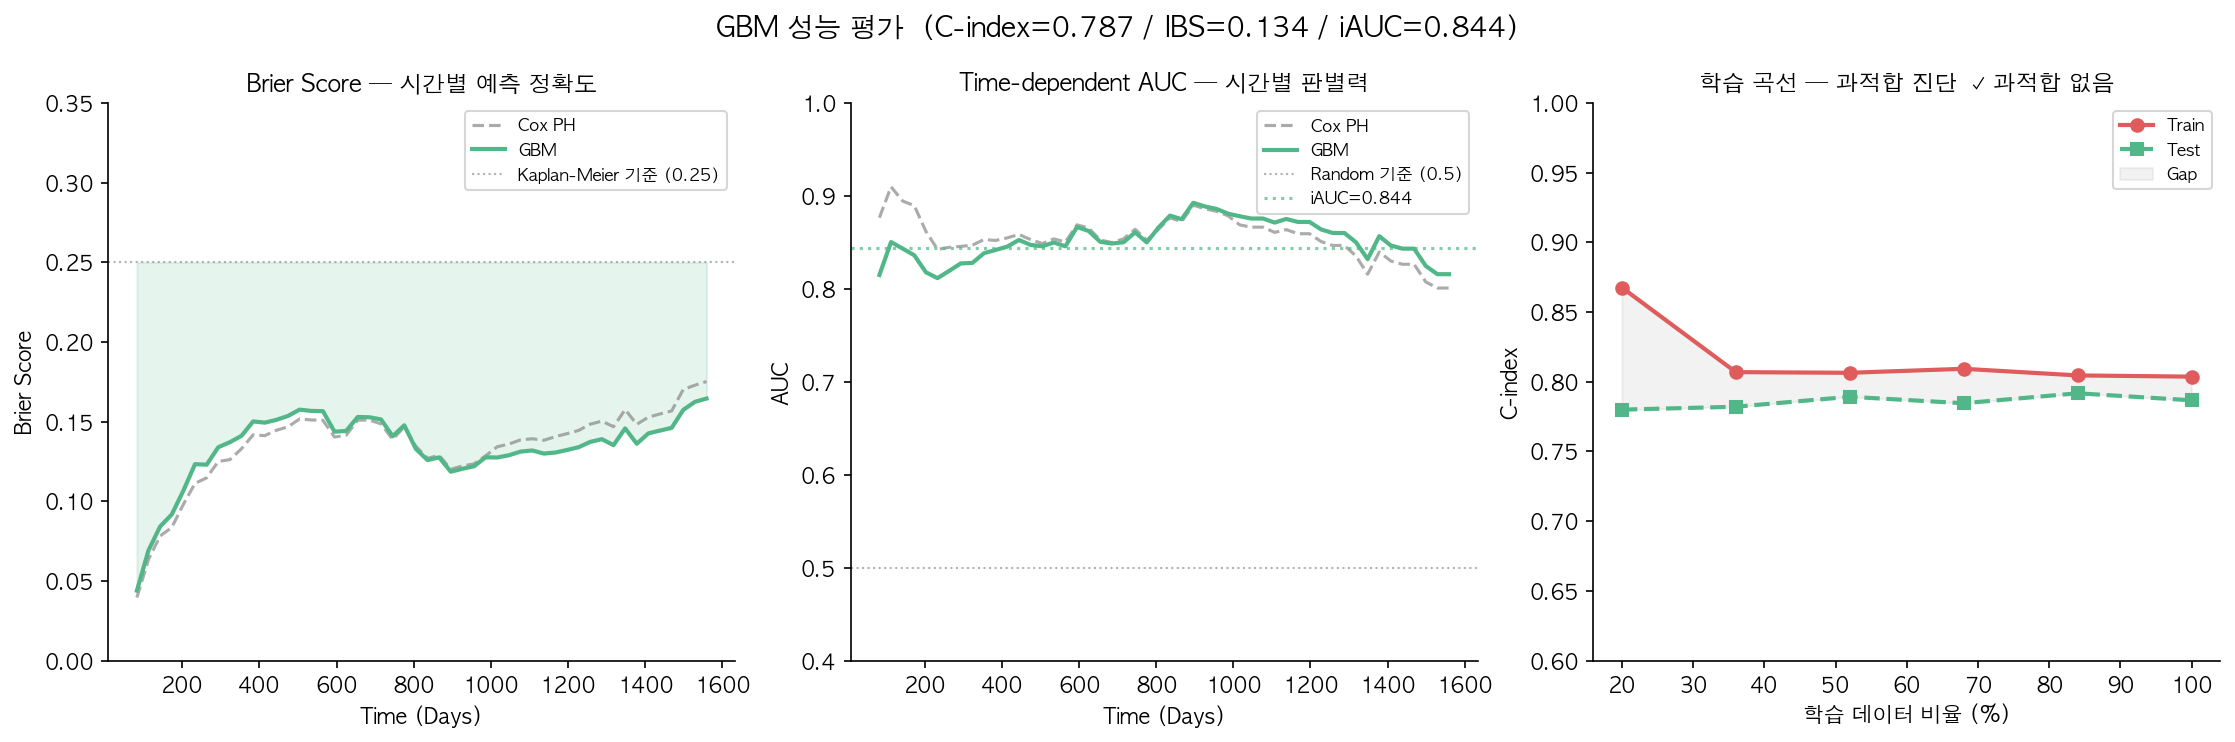

✓ fig_gbm_performance.png 저장 완료

STEP 4. 전체 모델 성능 비교

=== 전체 모델 성능 비교 ===
 Model  C-index_test C-index_5CV   IBS  iAUC
Cox PH         0.800 0.783±0.015 0.136 0.858
   RSF         0.783 0.785±0.016 0.138 0.840
   GBM         0.787 0.785±0.016 0.134 0.844

✓ table_model_performance_final.csv 저장 완료


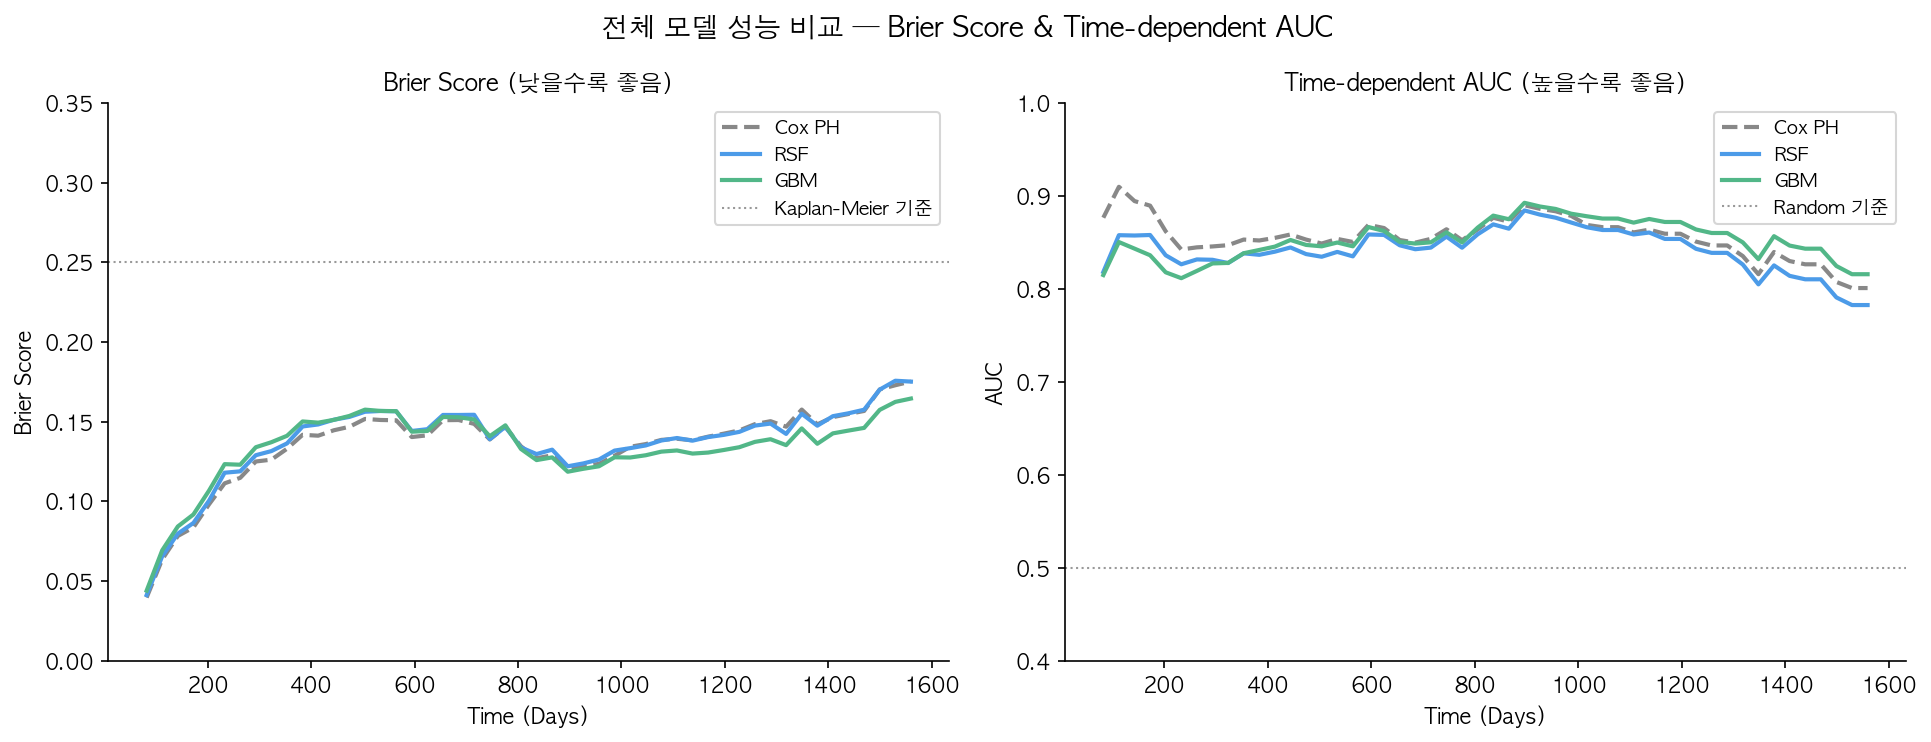

✓ fig_all_models_comparison.png 저장 완료

STEP 5. XAI 사전 준비 저장
✓ ml_models.pkl 저장 완료
  → NB 05 Global XAI에서 바로 불러와 사용

NB 04 완료 — 최종 성능 요약
Model         C-index           5-CV     IBS    iAUC
───────────────────────────────────────────────────────
Cox PH          0.800    0.783±0.015   0.136   0.858
RSF             0.783    0.785±0.016   0.138   0.840
GBM             0.787    0.785±0.016   0.134   0.844

→ 다음: NB 05 Global XAI (RSF + GBM 대상)


In [1]:
# ============================================================
# NB 04. ML 생존모형 — RSF · GBM 
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

from sksurv.ensemble import (
    RandomSurvivalForest,
    GradientBoostingSurvivalAnalysis
)
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc,
    brier_score
)
from sklearn.model_selection import StratifiedKFold, ParameterGrid

plt.rcParams.update({
    'font.family'      : 'AppleGothic',
    'axes.unicode_minus': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

OUTPUT_DIR = "./outputs/"
MODEL_DIR  = "./outputs/models/"
SEED       = 42
N_FOLDS    = 5
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
np.random.seed(SEED)

# ============================================================
# STEP 1. 데이터 준비
# ============================================================

print("="*55)
print("STEP 1. 데이터 준비")
print("="*55)

splits       = joblib.load(MODEL_DIR + "data_splits.pkl")
X_train_all  = splits['X_train']
X_test_all   = splits['X_test']
y_train      = splits['y_train']
y_test       = splits['y_test']
FEATURE_COLS = splits['feature_cols']

# Cox와 동일한 14개 피처
EXCLUDE_COLS = ['Age_Young', 'Age_Middle', 'Age_Old', 'Treatment']
ML_FEATURES  = [c for c in FEATURE_COLS if c not in EXCLUDE_COLS]

X_train = X_train_all[ML_FEATURES].copy().astype(float)
X_test  = X_test_all[ML_FEATURES].copy().astype(float)

# 평가 시간 구간 (Cox와 동일)
cox_perf = joblib.load(MODEL_DIR + "cox_performance.pkl")
times    = cox_perf['times']
cox_bs   = cox_perf['bs_scores']
cox_auc  = cox_perf['auc_scores']

CLINICAL_TIMES = [365, 730, 1095]

print(f"Train : {len(X_train):,}명  |  Test : {len(X_test):,}명")
print(f"피처  : {len(ML_FEATURES)}개 (Cox와 동일)")
print(f"평가  : {times.min():.0f}일 ~ {times.max():.0f}일")
print(f"\n피처 목록:")
for col in ML_FEATURES:
    print(f"  {col}")

events = np.array([e for e, _ in y_train])
skf    = StratifiedKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=SEED
)

# ============================================================
# 공통 함수
# ============================================================

def grid_search_cv(model_cls, param_grid, X, y, skf, events):
    """
    Grid Search + 5-Fold CV
    NB 03 Cox penalizer 탐색과 동일한 방법론
    """
    best_score  = -np.inf
    best_params = None
    gs_results  = []
    grid        = list(ParameterGrid(param_grid))

    print(f"총 {len(grid)}개 조합 × {N_FOLDS}-Fold = "
          f"{len(grid) * N_FOLDS}번 학습")

    for i, params in enumerate(grid):
        fold_scores = []
        for tr_idx, val_idx in skf.split(X, events):
            try:
                m = model_cls(random_state=SEED, **params)
                m.fit(X.iloc[tr_idx], y[tr_idx])
                c = concordance_index_censored(
                    y[val_idx]['event'],
                    y[val_idx]['time'],
                    m.predict(X.iloc[val_idx])
                )[0]
                fold_scores.append(c)
            except Exception:
                fold_scores.append(0.5)

        mean_c = float(np.mean(fold_scores))
        std_c  = float(np.std(fold_scores))
        gs_results.append({
            **params,
            'cv_mean': round(mean_c, 4),
            'cv_std' : round(std_c, 4),
        })
        if mean_c > best_score:
            best_score  = mean_c
            best_params = params

        if (i + 1) % 10 == 0 or (i + 1) == len(grid):
            print(f"  [{i+1:3d}/{len(grid)}] "
                  f"현재 최고 CV: {best_score:.3f}")

    return best_params, best_score, gs_results


def overfitting_cv(model_cls, params, X, y, skf, events):
    """
    과적합 검증 전용 5-Fold CV
    NB 03 Cox 과적합 검증과 동일한 방법론
    """
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X, events)
    ):
        m = model_cls(random_state=SEED, **params)
        m.fit(X.iloc[tr_idx], y[tr_idx])
        c = concordance_index_censored(
            y[val_idx]['event'],
            y[val_idx]['time'],
            m.predict(X.iloc[val_idx])
        )[0]
        fold_scores.append(c)
        print(f"  Fold {fold+1}: C-index = {c:.3f}")
    return float(np.mean(fold_scores)), float(np.std(fold_scores))


def compute_metrics(model, X_tr, X_te, y_tr, y_te, times):
    """C-index / IBS / iAUC / Brier / AUC 계산"""
    risk_tr = model.predict(X_tr)
    risk_te = model.predict(X_te)
    sm_te   = np.row_stack([
        fn(times)
        for fn in model.predict_survival_function(X_te)
    ])
    sm_tr   = np.row_stack([
        fn(times)
        for fn in model.predict_survival_function(X_tr)
    ])
    c_tr = concordance_index_censored(
        y_tr['event'], y_tr['time'], risk_tr
    )[0]
    c_te = concordance_index_censored(
        y_te['event'], y_te['time'], risk_te
    )[0]
    ibs_te = integrated_brier_score(y_tr, y_te, sm_te, times)
    ibs_tr = integrated_brier_score(y_tr, y_tr, sm_tr, times)
    _, bs  = brier_score(y_tr, y_te, sm_te, times)
    auc_arr, mean_auc = cumulative_dynamic_auc(
        y_tr, y_te, risk_te, times
    )
    return {
        'c_train'   : round(float(c_tr), 3),
        'c_test'    : round(float(c_te), 3),
        'ibs_train' : round(float(ibs_tr), 3),
        'ibs_test'  : round(float(ibs_te), 3),
        'iauc'      : round(float(mean_auc), 3),
        'bs_scores' : bs,
        'auc_scores': auc_arr,
        'sm_te'     : sm_te,
        'risk_te'   : risk_te,
    }


def learning_curve(model_cls, params, X_tr, y_tr,
                   X_te, y_te, n_steps=6):
    """학습 곡선 — NB 03 Cox와 동일한 방식"""
    sizes        = np.linspace(0.2, 1.0, n_steps)
    lc_tr, lc_te = [], []
    for size in sizes:
        n   = max(int(len(X_tr) * size), 50)
        idx = np.random.choice(len(X_tr), n, replace=False)
        m   = model_cls(random_state=SEED, **params)
        m.fit(X_tr.iloc[idx], y_tr[idx])
        lc_tr.append(concordance_index_censored(
            y_tr[idx]['event'], y_tr[idx]['time'],
            m.predict(X_tr.iloc[idx])
        )[0])
        lc_te.append(concordance_index_censored(
            y_te['event'], y_te['time'],
            m.predict(X_te)
        )[0])
    return lc_tr, lc_te, sizes


def clinical_auc(model, X_te, y_tr, y_te, clinical_times):
    """임상 시점별 AUC (1년/2년/3년)"""
    risk_te  = model.predict(X_te)
    te_times = np.array([t for _, t in y_te])
    results  = {}
    for t in clinical_times:
        if t <= te_times.min() or t >= te_times.max():
            continue
        try:
            auc, _ = cumulative_dynamic_auc(
                y_tr, y_te, risk_te, np.array([float(t)])
            )
            results[t] = round(float(auc[0]), 3)
        except Exception:
            results[t] = None
    return results


def plot_model_performance(name, metrics, lc_tr, lc_te,
                           sizes, color, fname):
    """
    성능 Figure — Brier / AUC / 학습곡선
    NB 03 Cox 성능 평가 Figure와 동일한 구조
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{name} 성능 평가  "
        f"(C-index={metrics['c_test']:.3f} / "
        f"IBS={metrics['ibs_test']:.3f} / "
        f"iAUC={metrics['iauc']:.3f})",
        fontsize=13, fontweight='bold'
    )

    # Brier Score
    ax = axes[0]
    ax.plot(times, cox_bs, color='#888888',
            linewidth=1.5, linestyle='--',
            label='Cox PH', alpha=0.7)
    ax.plot(times, metrics['bs_scores'],
            color=color, linewidth=2, label=name)
    ax.axhline(0.25, color='gray', linestyle=':',
               linewidth=1, alpha=0.6,
               label='Kaplan-Meier 기준 (0.25)')
    ax.fill_between(
        times, metrics['bs_scores'], 0.25,
        where=[b < 0.25 for b in metrics['bs_scores']],
        alpha=0.15, color=color
    )
    ax.set_title("Brier Score — 시간별 예측 정확도",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Time (Days)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(0, 0.35)
    ax.legend(fontsize=8)

    # Time-dependent AUC
    ax = axes[1]
    ax.plot(times, cox_auc, color='#888888',
            linewidth=1.5, linestyle='--',
            label='Cox PH', alpha=0.7)
    ax.plot(times, metrics['auc_scores'],
            color=color, linewidth=2, label=name)
    ax.axhline(0.5, color='gray', linestyle=':',
               linewidth=1, alpha=0.6,
               label='Random 기준 (0.5)')
    ax.axhline(metrics['iauc'], color=color,
               linestyle=':', linewidth=1.5, alpha=0.7,
               label=f"iAUC={metrics['iauc']:.3f}")
    ax.set_title("Time-dependent AUC — 시간별 판별력",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Time (Days)")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8)

    # 학습 곡선
    ax = axes[2]
    pct = sizes * 100
    ax.plot(pct, lc_tr, 'o-',
            color='#E05C5C', linewidth=2, label='Train')
    ax.plot(pct, lc_te, 's--',
            color=color, linewidth=2, label='Test')
    ax.fill_between(pct, lc_tr, lc_te,
                    alpha=0.1, color='gray', label='Gap')
    diff = np.array(lc_tr)[-1] - np.array(lc_te)[-1]
    status = '✓ 과적합 없음' if diff <= 0.05 else '[주의]'
    ax.set_title(f"학습 곡선 — 과적합 진단  {status}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("학습 데이터 비율 (%)")
    ax.set_ylabel("C-index")
    ax.set_ylim(0.6, 1.0)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + fname)
    plt.show()
    print(f"✓ {fname} 저장 완료")


def print_summary(name, metrics, cv_mean, cv_std,
                  best_params, clinical):
    """성능 요약 출력 — NB 03과 동일한 형식"""
    diff    = metrics['c_train'] - metrics['c_test']
    cv_diff = abs(cv_mean - metrics['c_test'])
    print(f"\n{'='*50}")
    print(f"Model   : {name}")
    print(f"{'─'*50}")
    print(f"최적 파라미터 : {best_params}")
    print(f"{'─'*50}")
    print(f"C-index  Train : {metrics['c_train']:.3f}")
    print(f"C-index  Test  : {metrics['c_test']:.3f}  ← 비교 기준")
    print(f"C-index  5-CV  : {cv_mean:.3f} ± {cv_std:.3f}")
    print(f"IBS      Train : {metrics['ibs_train']:.3f}")
    print(f"IBS      Test  : {metrics['ibs_test']:.3f}")
    print(f"iAUC           : {metrics['iauc']:.3f}")
    print(f"{'─'*50}")
    print(f"임상 시점별 AUC:")
    for t, auc in clinical.items():
        print(f"  {t}일({t//365}년): {auc}")
    print(f"{'─'*50}")
    print(f"{'✓' if diff <= 0.05 else '[주의]'} "
          f"Train-Test 차이 {diff:.3f} → "
          f"과적합 {'없음' if diff <= 0.05 else '의심'}")
    print(f"{'✓' if cv_diff < 0.03 else '[주의]'} "
          f"CV-Test 차이 {cv_diff:.3f}")
    print(f"{'='*50}")


# ============================================================
# STEP 2. RSF — Grid Search CV
# ============================================================

print("\n" + "="*55)
print("STEP 2. RSF — Grid Search CV")
print("="*55)

RSF_GRID = {
    'n_estimators'    : [100, 200, 500],
    'max_features'    : ['sqrt', 0.3, 0.5],
    'min_samples_leaf': [5, 10, 15, 20],
    'n_jobs'          : [-1],
}

best_rsf_params, best_rsf_score, rsf_gs = grid_search_cv(
    RandomSurvivalForest, RSF_GRID,
    X_train, y_train, skf, events
)

print(f"\n✓ 최적 파라미터 : {best_rsf_params}")
print(f"✓ CV C-index    : {best_rsf_score:.3f}")

pd.DataFrame(rsf_gs).to_csv(
    OUTPUT_DIR + "table_rsf_gridsearch.csv",
    index=False, encoding='utf-8-sig'
)
print("✓ table_rsf_gridsearch.csv 저장 완료")

# 전체 Train 재학습
rsf_best = RandomSurvivalForest(
    random_state=SEED, **best_rsf_params
)
rsf_best.fit(X_train, y_train)

# 성능 계산
rsf_metrics = compute_metrics(
    rsf_best, X_train, X_test, y_train, y_test, times
)

# 과적합 검증 CV
print("\n[ RSF 과적합 검증 — 5-Fold CV ]")
rsf_params_cv = {
    k: v for k, v in best_rsf_params.items()
    if k != 'n_jobs'
}
rsf_cv_mean, rsf_cv_std = overfitting_cv(
    RandomSurvivalForest, rsf_params_cv,
    X_train, y_train, skf, events
)

# 임상 시점별 AUC
rsf_clinical = clinical_auc(
    rsf_best, X_test, y_train, y_test, CLINICAL_TIMES
)

print_summary(
    'RSF', rsf_metrics,
    rsf_cv_mean, rsf_cv_std,
    best_rsf_params, rsf_clinical
)

# 학습 곡선
lc_tr_rsf, lc_te_rsf, sizes_rsf = learning_curve(
    RandomSurvivalForest, rsf_params_cv,
    X_train, y_train, X_test, y_test
)

# 성능 Figure
plot_model_performance(
    'RSF', rsf_metrics,
    lc_tr_rsf, lc_te_rsf, sizes_rsf,
    '#4C9BE8', 'fig_rsf_performance.png'
)

# ============================================================
# STEP 3. GBM — Grid Search CV
# ============================================================

print("\n" + "="*55)
print("STEP 3. GBM — Grid Search CV")
print("="*55)

GBM_GRID = {
    'n_estimators' : [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [2, 3, 4],
    'subsample'    : [0.6, 0.8, 1.0],
}

best_gbm_params, best_gbm_score, gbm_gs = grid_search_cv(
    GradientBoostingSurvivalAnalysis, GBM_GRID,
    X_train, y_train, skf, events
)

print(f"\n✓ 최적 파라미터 : {best_gbm_params}")
print(f"✓ CV C-index    : {best_gbm_score:.3f}")

pd.DataFrame(gbm_gs).to_csv(
    OUTPUT_DIR + "table_gbm_gridsearch.csv",
    index=False, encoding='utf-8-sig'
)
print("✓ table_gbm_gridsearch.csv 저장 완료")

# 전체 Train 재학습
gbm_best = GradientBoostingSurvivalAnalysis(
    random_state=SEED, **best_gbm_params
)
gbm_best.fit(X_train, y_train)

# 성능 계산
gbm_metrics = compute_metrics(
    gbm_best, X_train, X_test, y_train, y_test, times
)

# 과적합 검증 CV
print("\n[ GBM 과적합 검증 — 5-Fold CV ]")
gbm_cv_mean, gbm_cv_std = overfitting_cv(
    GradientBoostingSurvivalAnalysis, best_gbm_params,
    X_train, y_train, skf, events
)

# 임상 시점별 AUC
gbm_clinical = clinical_auc(
    gbm_best, X_test, y_train, y_test, CLINICAL_TIMES
)

print_summary(
    'GBM', gbm_metrics,
    gbm_cv_mean, gbm_cv_std,
    best_gbm_params, gbm_clinical
)

# 학습 곡선
lc_tr_gbm, lc_te_gbm, sizes_gbm = learning_curve(
    GradientBoostingSurvivalAnalysis, best_gbm_params,
    X_train, y_train, X_test, y_test
)

# 성능 Figure
plot_model_performance(
    'GBM', gbm_metrics,
    lc_tr_gbm, lc_te_gbm, sizes_gbm,
    '#52B788', 'fig_gbm_performance.png'
)

# ============================================================
# STEP 4. 전체 모델 성능 비교
# ============================================================

print("\n" + "="*55)
print("STEP 4. 전체 모델 성능 비교")
print("="*55)

cox_performance = cox_perf['performance']
cox_cv_mean     = cox_perf.get('cv_mean', None)
cox_cv_std      = cox_perf.get('cv_std', None)

df_perf = pd.DataFrame([
    {
        'Model'        : 'Cox PH',
        'C-index_train': cox_perf.get(
            'c_index_train', cox_performance['C-index']
        ),
        'C-index_test' : cox_performance['C-index'],
        'C-index_5CV'  : (
            f"{cox_cv_mean:.3f}±{cox_cv_std:.3f}"
            if cox_cv_mean else '-'
        ),
        'IBS'          : cox_performance['IBS'],
        'iAUC'         : cox_performance['iAUC'],
    },
    {
        'Model'        : 'RSF',
        'C-index_train': rsf_metrics['c_train'],
        'C-index_test' : rsf_metrics['c_test'],
        'C-index_5CV'  : f"{rsf_cv_mean:.3f}±{rsf_cv_std:.3f}",
        'IBS'          : rsf_metrics['ibs_test'],
        'iAUC'         : rsf_metrics['iauc'],
    },
    {
        'Model'        : 'GBM',
        'C-index_train': gbm_metrics['c_train'],
        'C-index_test' : gbm_metrics['c_test'],
        'C-index_5CV'  : f"{gbm_cv_mean:.3f}±{gbm_cv_std:.3f}",
        'IBS'          : gbm_metrics['ibs_test'],
        'iAUC'         : gbm_metrics['iauc'],
    },
])

print("\n=== 전체 모델 성능 비교 ===")
print(df_perf[[
    'Model', 'C-index_test', 'C-index_5CV', 'IBS', 'iAUC'
]].to_string(index=False))

df_perf.to_csv(
    OUTPUT_DIR + "table_model_performance_final.csv",
    index=False, encoding='utf-8-sig'
)
print("\n✓ table_model_performance_final.csv 저장 완료")

# 전체 비교 Figure
COLORS = {
    'Cox PH': '#888888',
    'RSF'   : '#4C9BE8',
    'GBM'   : '#52B788',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "전체 모델 성능 비교 — Brier Score & Time-dependent AUC",
    fontsize=13, fontweight='bold'
)

ax = axes[0]
for name, arr in [
    ('Cox PH', cox_bs),
    ('RSF', rsf_metrics['bs_scores']),
    ('GBM', gbm_metrics['bs_scores']),
]:
    ls = '--' if name == 'Cox PH' else '-'
    ax.plot(times, arr, color=COLORS[name],
            linewidth=2, linestyle=ls, label=name)
ax.axhline(0.25, color='black', linestyle=':',
           linewidth=1, alpha=0.4,
           label='Kaplan-Meier 기준')
ax.set_title("Brier Score (낮을수록 좋음)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Brier Score")
ax.set_ylim(0, 0.35)
ax.legend(fontsize=9)

ax = axes[1]
for name, arr in [
    ('Cox PH', cox_auc),
    ('RSF', rsf_metrics['auc_scores']),
    ('GBM', gbm_metrics['auc_scores']),
]:
    ls = '--' if name == 'Cox PH' else '-'
    ax.plot(times, arr, color=COLORS[name],
            linewidth=2, linestyle=ls, label=name)
ax.axhline(0.5, color='black', linestyle=':',
           linewidth=1, alpha=0.4,
           label='Random 기준')
ax.set_title("Time-dependent AUC (높을수록 좋음)",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Time (Days)")
ax.set_ylabel("AUC")
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig_all_models_comparison.png")
plt.show()
print("✓ fig_all_models_comparison.png 저장 완료")

# ============================================================
# STEP 5. XAI 사전 준비 저장
# ============================================================

print("\n" + "="*55)
print("STEP 5. XAI 사전 준비 저장")
print("="*55)

joblib.dump({
    # 모델
    'rsf_best'       : rsf_best,
    'gbm_best'       : gbm_best,

    # 피처 (14개)
    'ml_features'    : ML_FEATURES,

    # SHAP 배경 데이터 (100개 샘플)
    'X_background'   : X_train.sample(100, random_state=SEED),
    'X_train'        : X_train,
    'X_test'         : X_test,

    # 생존행렬
    'rsf_surv_matrix': rsf_metrics['sm_te'],
    'gbm_surv_matrix': gbm_metrics['sm_te'],

    # 위험점수
    'risk_rsf'       : rsf_metrics['risk_te'],
    'risk_gbm'       : gbm_metrics['risk_te'],

    # 평가 시간 구간
    'times'          : times,
    'clinical_times' : CLINICAL_TIMES,

    # 성능 테이블
    'performance_table': df_perf,

    # 하이퍼파라미터
    'best_rsf_params': best_rsf_params,
    'best_gbm_params': best_gbm_params,

    # CV 결과
    'rsf_cv_mean'    : rsf_cv_mean,
    'rsf_cv_std'     : rsf_cv_std,
    'gbm_cv_mean'    : gbm_cv_mean,
    'gbm_cv_std'     : gbm_cv_std,

    # y 데이터 (SurvSHAP(t) 필요)
    'y_train'        : y_train,
    'y_test'         : y_test,

}, MODEL_DIR + "ml_models.pkl")

print("✓ ml_models.pkl 저장 완료")
print("  → NB 05 Global XAI에서 바로 불러와 사용")

# 최종 요약
print(f"\n{'='*55}")
print("NB 04 완료 — 최종 성능 요약")
print(f"{'='*55}")
print(f"{'Model':12s} {'C-index':>8s} {'5-CV':>14s} "
      f"{'IBS':>7s} {'iAUC':>7s}")
print(f"{'─'*55}")
for _, row in df_perf.iterrows():
    print(f"{row['Model']:12s} {row['C-index_test']:>8.3f} "
          f"{str(row['C-index_5CV']):>14s} "
          f"{row['IBS']:>7.3f} {row['iAUC']:>7.3f}")
print(f"{'='*55}")
print("\n→ 다음: NB 05 Global XAI (RSF + GBM 대상)")